# LEARNING OBJECTIVE

This notebook demonstrates basic 2D ideal flows in plane starting from a complex potential $F(z)$. In doing so, techniques for visualizing equipotential lines ($\phi=const.$) and streamlines ($\psi=const.$) are reviewed. The connection between polar and Cartesian representations of complex numbers and between velocity components in polar and Cartesian coordnate systems is also reviewed. SymPy is used to do the vector calculus to demonstarte that the flow fields found from $F$ are incompressible and irrotational.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [81]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import colors, colormaps
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# IDEAL FLOWS

**Definition:** Ideal flows (also known as [potential flows](https://en.wikipedia.org/wiki/Potential_flow) are fluid flows that are incompressible ($\nabla\cdot\underline{v}=0$) and irrotational ($\nabla\times\underline{v} \equiv \underline{\omega} = \underline{0}$) and, consequently inviscid (i.e., there are no viscous _forces_ in the flow).

The inviscid bit follows from the fact that, in the incompressible Navier&ndash;Stokes (iNS) equations for a Newtonain fluid, the viscous forces (per unit volume) are given by $\nabla\cdot\underline{\underline{\tau}}=\mu\nabla^2\underline{v} \equiv -\mu\nabla\times\underline{\omega}$ (via several vector calculus identities) and, thus, vanish for irrotational incompressible flow because $\nabla\times\underline{0} = \underline{0}$.

**Note:** abscence of viscous _forces_, computed as $\nabla\cdot\underline{\underline{\tau}}$, does **not** preclude the existence of viscous _stresses_, computed as the components of $\underline{\underline{\tau}}$, in the flow!

## In the plane

In the $(x,y)$ plane (2D), ideal flows can be represented by either a (scalar) [potential function](https://en.wikipedia.org/wiki/Velocity_potential) $\phi(x,y)$ (since $\nabla\times\underline{v}=\underline{0}$, then we can always write $\underline{v} = \nabla\phi$; this is an identity) or a (scalar) [streamfunction](https://en.wikipedia.org/wiki/Stream_function) $\psi(x,y)$ (which is defined such that $\nabla\cdot\underline{v} = 0$ is automatically satisfied).

The "compatibility relations" 
\begin{align*}
    v_x(x,y) &= \partial_x \phi(x,y) = \partial_y \psi(x,y),\\
    v_y(x,y) &= \partial_y \phi(x,y) = -\partial_x \psi(x,y),
\end{align*} 
turn out to be the [Cauchy&ndash;Riemann equations](https://en.wikipedia.org/wiki/Cauchy%E2%80%93Riemann_equations) ensuring the differentiability of the complex-valued function $F(z) = \phi(x,i) + i \psi(x,y)$, where $i=\sqrt{-1}$ and $z=x+iy$.

Thus, any differntiable $F(z)$ gives rise to an ideal flow. Cool, huh? Let's try a few example $F(z)$ and visualize the resulting flows via $\phi$, $\psi$ and $\underline{v}$.

# EXAMPLES


First, setup an uniform $(x,y)$ mesh in 2D to use for all plotting.

In [82]:
# range
xmax = 5
ymax = 5

# grid, picking an even num to avoid (0,0) being in the plotting points
# obviously, "bad things" happen at the origin when we go to polar coords
x, y = np.meshgrid( np.linspace(-xmax, xmax, num=56),
                    np.linspace(-ymax, ymax, num=56) )

# convert (x,y) to (r,th) for plotting in polar coordinates
# note: arctan2(y,x) computes arctangent(y/x) taking into account the
# signs of x and y, which is important for these problems.
# if you use atan(y/x), you'd get funny results due to the 'branch cut' of atan.
r = np.sqrt(x**2 + y**2)
th = np.arctan2(y,x)

## Uniform ideal flow at an angle


### Complex potential

Consider $F(z) = A z$, where $A = a + i b = |A| e^{i\alpha}$ is a _complex_ number.

Since the product of two complex numbers would "mix up" the real and imaginary parts of both, we might anticipate that's not the best approach.

Let's try working in polar coordinates ($r = \sqrt{x^2+y^2}$ and $\theta = \tan^{-1}(y/x)$), then we have
\begin{align*}
\phi(r,\theta) &= \mathrm{Re}[F] = |A|r\cos(\theta+\alpha),\\
\psi(r,\theta) &= \mathrm{Im}[F] = |A|r\sin(\theta+\alpha).
\end{align*}

Let's take $|A|=1$, plot the <font color="red">equipotential</font> and <font color="blue">stream</font> lines, and vary $\alpha$ (in degrees).

In [83]:
def plot_func(α):
  phi = r*np.cos(th + α/180*np.pi)
  psi = r*np.sin(th + α/180*np.pi)

  fig, ax = plt.subplots()
  ax.set_xlabel('$x$')
  ax.set_ylabel('$y$')
  ax.set_aspect('equal')

  # plot contour lines corresponding to planar curves y = f(x) of constant phi
  # these are the "equipotential lines"
  csphi = ax.contour(x, y, phi, 10, colors='red')

  # plot contour lines corresponding to planar curves y = f(x) of constant psi
  # these are the "stream lines"
  cspsi = ax.contour(x, y, psi, 10, colors='blue')

  # label the contours with their values
  ax.clabel(csphi, inline=1, fontsize=10)
  ax.clabel(cspsi, inline=1, fontsize=10)

  # make the output figure a bit larger
  fig.set_size_inches(8, 6)
  plt.show()

# note: alpha on the slider is in *degrees*
interact(plot_func, α = widgets.FloatSlider( value = 0,
                                             min   = -90,
                                             max   = +90,
                                             step  = 5 ) );

interactive(children=(FloatSlider(value=0.0, description='α', max=90.0, min=-90.0, step=5.0), Output()), _dom_…

The streamlines are at an angle to the axes, this suggest the direction of the flow and its features. Plotting the velocity might be helpful too in visualizing the flow.

### Velocity profile

We find it two ways.

First, we find the complex velocity:
$$
  W(z) = \frac{dF}{dz} = A = |A|(e^{i\alpha}e^{i\theta})e^{-i\theta} = \big\{ {\color{magenta}{|A|\cos(\theta+\alpha)}}\color{red}{-i}[\color{magenta}{-|A|\sin(\theta+\alpha)}]\big\}{\color{red}{e^{-i\theta}}}.
$$
From which we read off the <font color="magenta">magenta</font> terms (the red ones have to be there in the definition relating the velocity components to $W$):
\begin{align*}
  v_r(r,\theta) &= |A| \cos(\theta+\alpha),\\
  v_\theta(r,\theta) &= -|A| \sin(\theta+\alpha).\\
\end{align*}

Second, we compute $\underline{v} = \nabla \phi$ in polar coordinates directly using SymPy's [`vector`](https://docs.sympy.org/latest/modules/vector/index.html) module:

In [84]:
c = CoordSys3D('c')
cp = c.create_new('cp', transformation='cylindrical',
                  vector_names=("r", "th", "z"),
                  variable_names=("R", "Th", "Z"))

# print change of coordinates formula for our reference
cp.transformation_to_parent()

In [85]:
# the velocity = grad phi
alpha, phi, A = sp.symbols('alpha phi A')
phi = A*cp.R*sp.cos(cp.Th + alpha)
gradient(phi)

**Caution:** the returned velocity vector is in the transformed coordinate system, clearly the unit vectors are in that system. A transformation is required to get Cartesian components. Matplotlib's (or MATLAB's and so on) plotting functions expect Cartesian velocity components.

In [86]:
# divergence of v
divergence(gradient(phi))

In [87]:
# curl of v
curl(gradient(phi))

In [ ]:
def plot_func(α):
  # the cartesian velocities diretly from dF/dZ
  #vr = np.cos(α/180*np.pi)
  #vth = -np.sin(α/180*np.pi)

  # the polar velocities computed with SymPy above
  vr = np.cos(th + α/180*np.pi)
  vth = -np.sin(th + α/180*np.pi)

  # transform polar velocities to Cartesian ones for plotting
  vx = vr*np.cos(th) - vth*np.sin(th)
  vy = vr*np.sin(th) + vth*np.cos(th)

  fig, (ax1, ax2) = plt.subplots(1,2)

  ax1.set_xlabel('$x$')
  ax1.set_ylabel('$y$')
  ax1.set_title('quiver plot')
  ax1.set_aspect('equal')

  # skip every fourth point when plotting velocity vectors, for clarity
  ax1.quiver(x[::4,::4], y[::4,::4], vx[::4,::4], vy[::4,::4],
              scale=1, scale_units='xy', color='blue')

  ax2.set_xlabel('$x$')
  ax2.set_ylabel('$y$')
  ax2.set_title('stream plot')
  ax2.set_aspect('equal')

  strm = ax2.streamplot(x, y, vx, vy,
                        color=np.sqrt(vx**2+vy**2), linewidth=2,
                        cmap=colormaps['YlGnBu_r'])

  # make the colorabar look nice ...
  pos = ax2.get_position()
  pad, width = 0.03, 0.03
  ax3 = fig.add_axes([pos.xmax + pad, pos.ymin + 2*pad, width, 0.7*(pos.ymax-pos.ymin) ])
  fig.colorbar(strm.lines, cax=ax3, label=r'$\sqrt{v_x^2+v_y^2}$')

  fig.set_size_inches(10, 8)
  plt.show()

# alpha on the slider is in degrees
interact(plot_func, α = widgets.FloatSlider( value = 0,
                                             min   = -90,
                                             max   = +90,
                                             step  = 5 ) );

interactive(children=(FloatSlider(value=0.0, description='α', max=90.0, min=-90.0, step=5.0), Output()), _dom_…

**Note:** although the velocity is supposed to be uniformly $=|A|=1$ in magnitude, there maye be some discretization error in the streamplot up to $\pm10\%$ (as suggested by the colorbar).

## Ideal stagnation point flow

### Complex potential

Consider $F(z) = z^2$, on your own (based on the intiution from the previous example, you may also consider $Az^2$, where $A$ is a comlex number).

Some quick algebra leads us to:
\begin{align*}
\phi(r,\theta) &= \mathrm{Re}[F] = x^2 - y^2,\\
\psi(r,\theta) &= \mathrm{Im}[F] = 2xy.
\end{align*}

Let's plot the <font color="red">equipotential</font> and <font color="blue">stream</font> lines.

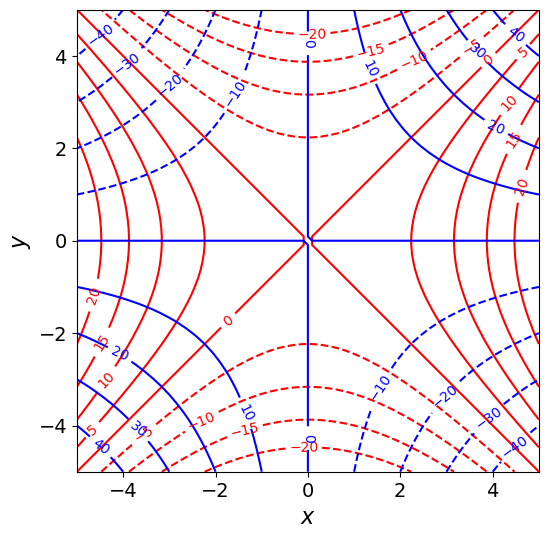

In [89]:
phi = x**2 - y**2
psi = 2*x*y

fig, ax = plt.subplots()
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_aspect('equal')

# plot contour lines corresponding to planar curves y = f(x) of constant phi
# these are the "equipotential lines", the function picks 10 equispaced ones
csphi = ax.contour(x, y, phi, 10, colors='red')

# plot contour lines corresponding to planar curves y = f(x) of constant psi
# these are the "stream lines", the function picks 10 equispaced ones
cspsi = ax.contour(x, y, psi, 10, colors='blue')

# label the contours with their values
ax.clabel(csphi, inline=1, fontsize=10)
ax.clabel(cspsi, inline=1, fontsize=10)

fig.set_size_inches(8, 6)

### Velocity profile

We find it two ways.

First, we find the complex velocity:
$$
  W(z) = \frac{dF}{dz} = 2z = {\color{magenta}{2x}} {\color{red}{-i}} ({\color{magenta}{-2y}}).
$$
From which we read off the <font color="magenta">magenta</font> terms (the red ones have to be there in the definition relating the velocity components to $W$):
\begin{align*}
  v_x(x,y) &= 2x,\\
  v_y(x,y) &= -2y.\\
\end{align*}

Second, we compute $\underline{v} = \nabla \phi$ in Cartesian coordinates directly using SymPy's [`vector`](https://docs.sympy.org/latest/modules/vector/index.html) module:

In [90]:
c = CoordSys3D('c')

In [91]:
# the velocity
phi = c.x**2 - c.y**2
gradient(phi)

In [92]:
# divergence of v
divergence(gradient(phi))

In [93]:
# curl of v
curl(gradient(phi))

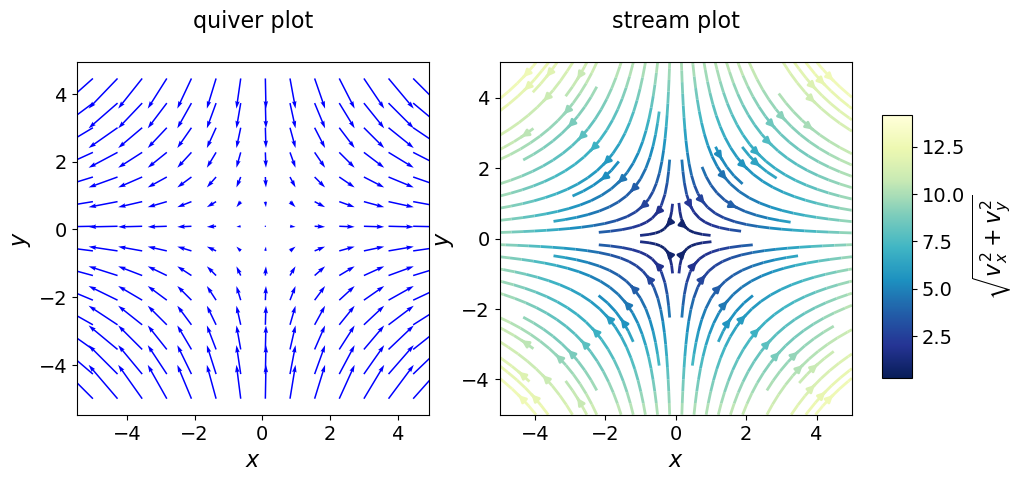

In [94]:
vx = 2*x
vy = -2*y

fig, (ax1, ax2) = plt.subplots(1,2)

ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.set_title('quiver plot')
ax1.set_aspect('equal')

# skip every fourth point when plotting velocity vectors, for clarity
ax1.quiver(x[::4,::4], y[::4,::4], vx[::4,::4], vy[::4,::4],
           scale=10, scale_units='xy', color='blue')

ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax2.set_title('stream plot')
ax2.set_aspect('equal')

strm = ax2.streamplot(x, y, vx, vy,
                      color=np.sqrt(vx**2+vy**2), linewidth=2,
                      cmap=colormaps['YlGnBu_r'])

# make the colorabar look nice ...
pos = ax2.get_position()
pad, width = 0.03, 0.03
ax3 = fig.add_axes([pos.xmax + pad, pos.ymin + 2*pad, width, 0.7*(pos.ymax-pos.ymin) ])
fig.colorbar(strm.lines, cax=ax3, label=r"$\sqrt{v_x^2+v_y^2}$")

fig.set_size_inches(10, 8)

**Note:** the quiver plot required a rescaling, using `scale` option of `quiver`, of the velocity vector sizes to make it easier to interpret.

For the stream plot, it is good to use a [sequential colormap](https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential) since we use the velocity magnitude (always positive) to color the streamlines. Darker colors = slower flow.

## Ideal wedge and corner flows

### Complex potential

Let's keep going and consider $F(z) = A z^{n}$, for any **noninteger** $n\ge1$, and _complex_ $A=|A|e^{i\alpha}$.

Again, it is best to proceed in polar coordinates ($r = \sqrt{x^2+y^2}$ and $\theta = \tan^{-1}(y/x)$) for general $n$ (_not_ $2$ or $1$ as above), then we have
$$
z^n = r^n e^{in\theta} = r^n\cos(n\theta) + i r^n\sin(n\theta).
$$
Thus:
\begin{align*}
\phi(r,\theta) &= \mathrm{Re}[F] = |A| r^{n}\cos(n\theta+\alpha),\\
\psi(r,\theta) &= \mathrm{Im}[F] = |A| r^{n}\sin(n\theta+\alpha).
\end{align*}

Let's take $A=-1$ ($\Rightarrow \alpha=\pm\pi$), plot the <font color="red">equipotential</font> and <font color="blue">stream</font> lines, and vary $n$.

In [95]:
def plot_func(n):
  phi = r**n*np.cos(n*th - np.pi)
  psi = r**n*np.sin(n*th - np.pi)

  fig, ax = plt.subplots()
  ax.set_xlabel('$x$')
  ax.set_ylabel('$y$')
  ax.set_aspect('equal')

  # plot contour lines corresponding to planar curves y = f(x) of constant phi
  # these are the "equipotential lines"
  csphi = ax.contour(x, y, phi, 10, colors='red')

  # plot contour lines corresponding to planar curves y = f(x) of constant psi
  # these are the "stream lines"
  cspsi = ax.contour(x, y, psi, 10, colors='blue')

  # label the contours with their values
  ax.clabel(csphi, inline=1, fontsize=10)
  ax.clabel(cspsi, inline=1, fontsize=10)

  # higlight the wedge/corner theta = -/+ pi/n
  ax.plot(x[1,:] , x[1,:]*np.tan(np.pi/n),
          linestyle='dotted', color='orange', linewidth=2)
  ax.plot(x[1,:] , x[1,:]*np.tan(-np.pi/n),
          linestyle='dotted', color='orange', linewidth=2)

  ax.set_xlim([-xmax, xmax])
  ax.set_ylim([-ymax, ymax])

  # make the output figure a bit larger
  fig.set_size_inches(8, 6)
  plt.show()

# note: alpha on the slider is in *degrees*
interact(plot_func, n = widgets.FloatSlider( value = 1.2,
                                             min   = 1,
                                             max   = 3,
                                             step  = 0.2 ) );

interactive(children=(FloatSlider(value=1.2, description='n', max=3.0, min=1.0, step=0.2), Output()), _dom_cla…

The dotted yellow lines denote a possible wedge/corner wall pair (producing a dotted almost-black line when shown on top of the blue streamline) such that $\theta = \pm \alpha/n$, for a total wedge/corner angle $2\pi-2|\alpha|/n$ (to reduce to an angle between $0$ and $2\pi$).

Observe that these are precisely the _zero_ streamline which is the curve such that
$$
  \psi(r,\theta) = |A| r^{n}\sin(n\theta+\alpha) = 0 \qquad \Leftrightarrow \qquad \sin(n\theta+\alpha) = 0.
$$
For $A = -1 = e^{\pm i \pi}$ this yields the two lines (_rays_)
$$
  \theta = \frac{\mp \pi}{n},\qquad r>0,
$$
for a total wedge/corner angle $2\pi(n-1)/n$.

### Velocity profile

We find it two ways.

First, we find the complex velocity:
\begin{align*}
  W(z) &= \frac{dF}{dz} = A n z^{n-1} = |A|e^{i\alpha}n(r^{n-1}e^{i(n-1)\theta}) = |A|n(e^{i\alpha}r^{n-1}e^{in\theta})e^{-i\theta} \\
  &= \big\{ {\color{magenta}{|A|nr^{n-1}\cos(n\theta+\alpha)}}\color{red}{-i}[\color{magenta}{-|A|nr^{n-1}\sin(n\theta+\alpha)}]\big\}{\color{red}{e^{-i\theta}}}.
\end{align*}
From which we read off the <font color="magenta">magenta</font> terms (the red ones have to be there in the definition relating the velocity components to $W$):
\begin{align*}
  v_r(r,\theta) &= |A| n r^{n-1} \cos(n\theta+\alpha),\\
  v_\theta(r,\theta) &= -|A| n r^{n-1} \sin(n\theta+\alpha).\\
\end{align*}

Second, we compute $\underline{v} = \nabla \phi$ in Cartesian coordinates directly using SymPy's [`vector`](https://docs.sympy.org/latest/modules/vector/index.html) module:

In [96]:
c = CoordSys3D('c')
cp = c.create_new('cp', transformation='cylindrical',
                  vector_names=("r", "th", "z"),
                  variable_names=("R", "Th", "Z"))

# print change of coordinates formula for our reference
cp.transformation_to_parent()

In [97]:
# the velocity = grad phi
n, phi, A = sp.symbols('n phi A')
phi = A*cp.R**n*sp.cos(n*cp.Th + alpha)
gradient(phi).simplify()

In [98]:
# divergence of v
divergence(gradient(phi))

In [99]:
# curl of v
curl(gradient(phi))

In [100]:
def plot_func(n):
  # the polar velocities computed with SymPy and from dF/dZ above
  vr = n*r**(n-1)*np.cos(n*th - np.pi)
  vth = -n*r**(n-1)*np.sin(n*th - np.pi)

  # transform polar velocities to Cartesian ones for plotting
  vx = vr*np.cos(th) - vth*np.sin(th)
  vy = vr*np.sin(th) + vth*np.cos(th)

  fig, (ax1, ax2) = plt.subplots(1,2)

  ax1.set_xlabel('$x$')
  ax1.set_ylabel('$y$')
  ax1.set_title('quiver plot')
  ax1.set_aspect('equal')

  # skip every fourth point when plotting velocity vectors, for clarity
  ax1.quiver(x[::4,::4], y[::4,::4], vx[::4,::4], vy[::4,::4],
              scale=(xmax**2+ymax**2)**((n-1)/2), scale_units='xy', color='blue')

  ax2.set_xlabel('$x$')
  ax2.set_ylabel('$y$')
  ax2.set_title('stream plot')
  ax2.set_aspect('equal')

  strm = ax2.streamplot(x, y, vx, vy,
                        color=np.sqrt(vx**2+vy**2), linewidth=2,
                        cmap=colormaps['YlGnBu']) # or YlGnBu_r

  # make the colorabar look nice ...
  pos = ax2.get_position()
  pad, width = 0.03, 0.03
  ax3 = fig.add_axes([pos.xmax + pad, pos.ymin + 2*pad, width, 0.7*(pos.ymax-pos.ymin) ])
  fig.colorbar(strm.lines, cax=ax3, label=r'$\sqrt{v_x^2+v_y^2}$')

  fig.set_size_inches(10, 8)
  plt.show()

# alpha on the slider is in degrees
interact(plot_func, n = widgets.FloatSlider( value = 1.2,
                                             min   = 1,
                                             max   = 3,
                                             step  = 0.2 ) );

interactive(children=(FloatSlider(value=1.2, description='n', max=3.0, min=1.0, step=0.2), Output()), _dom_cla…

We observe that for $1<n<2$, this $F(z)$ generates _wedge_ flows, while for $2<n$, it generates _corner_ flows.

**Note:** the quiver plots required a clever rescaling, using `scale` option of `quiver`, to make them readable.

The stream plot colormap was also reversed to show lighter colors as slower flow for clarity.

## Ideal vortex

### Complex potential

Consider $F(z) = \frac{i\Gamma}{2\pi}\log(z)$, where $\Gamma$ is a _real_ number.

The [complex logarithm](https://en.wikipedia.org/wiki/Complex_logarithm) is best calculated in polar coordinates. Thus, working in polar coordinates ($r = \sqrt{x^2+y^2}$ and $\theta = \tan^{-1}(y/x)$), we have
\begin{align*}
\phi(r,\theta) &= \mathrm{Re}[F] = -\frac{\Gamma}{2\pi}\theta,\\
\psi(r,\theta) &= \mathrm{Im}[F] = \frac{\Gamma}{2\pi}\ln r.
\end{align*}

Let's plot the <font color="red">equipotential</font> and <font color="blue">stream</font> lines, and vary $\Gamma$.

In [101]:
def plot_func(Γ):
  phi = -Γ/(2*np.pi)*th
  psi = Γ/(2*np.pi)*np.log(r)

  fig, ax = plt.subplots()
  ax.set_xlabel('$x$')
  ax.set_ylabel('$y$')
  ax.set_aspect('equal')

  # plot contour lines corresponding to planar curves y = f(x) of constant phi
  # these are the "equipotential lines", the function picks 10 equispaced ones
  csphi = ax.contour(x, y, phi, 10, colors='red')

  # plot contour lines corresponding to planar curves y = f(x) of constant psi
  # these are the "stream lines", the function picks 10 equispaced ones
  cspsi = ax.contour(x, y, psi, 10, colors='blue')

  # label the contours with their values
  ax.clabel(csphi, inline=1, fontsize=10)
  ax.clabel(cspsi, inline=1, fontsize=10)

  fig.set_size_inches(8, 6)
  plt.show()

interact(plot_func, Γ = widgets.FloatSlider( value = 1,
                                             min   = -5,
                                             max   = +5,
                                             step  = 0.2 ) );

interactive(children=(FloatSlider(value=1.0, description='Γ', max=5.0, min=-5.0, step=0.2), Output()), _dom_cl…

**Note:** the equipotential lines are all scrunched up around $\theta = \pi$ because of the [branch cut](https://en.wikipedia.org/wiki/Branch_point#Complex_logarithm) of the logarithm. One could play with the levels given to [`contour`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html) to make it look nicer...

### Velocity profile

We find it two ways.

First, we find the complex velocity:
$$
  W(z) = \frac{dF}{dz} = \frac{i\Gamma}{2\pi z} = \frac{\Gamma}{2\pi}i\frac{1}{re^{i\theta}} = \left\{ {\color{magenta}{0}} {\color{red}{- i}}\left({\color{magenta}{- \frac{\Gamma}{2\pi r}}}\right)\right\}{\color{red}{e^{-i\theta}}}.
$$
From which we read off the <font color="magenta">magenta</font> terms (the red ones have to be there in the definition relating the velocity components to $W$):
\begin{align*}
  v_r(r,\theta) &= 0,\\
  v_\theta(r,\theta) &= -\frac{\Gamma}{2\pi r}.\\
\end{align*}

Second, we compute $\underline{v} = \nabla \phi$ in polar coordinates directly using SymPy's [`vector`](https://docs.sympy.org/latest/modules/vector/index.html) module:

In [102]:
c = CoordSys3D('c')
cp = c.create_new('cp', transformation='cylindrical',
                  vector_names=("r", "th", "z"),
                  variable_names=("R", "Th", "Z"))

# change of coordinates formula
cp.transformation_to_parent()

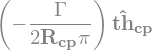

In [103]:
# the velocity
Gamma, phi = sp.symbols('Gamma phi')

phi = -Gamma/(2*sp.pi)*cp.Th
gradient(phi)

**Caution:** the returned velocity vector is in the transformed coordinate system, clearly the unit vectors are in that system. A transformation is required to get Cartesian components. Matplotlib's (or MATLAB's and so on) plotting functions expect Cartesian velocity components.

In [104]:
# divergence of v
divergence(gradient(phi))

In [105]:
# curl of v
curl(gradient(phi))

In [106]:
def plot_func(Γ):
  # the polar velocities computed with SymPy above
  vr = 0
  vth = -Γ/(2*np.pi*r)

  # transform polar velocities to Cartesian ones for plotting
  vx = vr*np.cos(th) - vth*np.sin(th)
  vy = vr*np.sin(th) + vth*np.cos(th)

  fig, (ax1, ax2) = plt.subplots(1,2)

  ax1.set_xlabel('$x$')
  ax1.set_ylabel('$y$')
  ax1.set_title('quiver plot')
  ax1.set_aspect('equal')

  # skip every fourth point when plotting velocity vectors, for clarity
  ax1.quiver(x[::4,::4], y[::4,::4], vx[::4,::4], vy[::4,::4],
              scale=0.1, scale_units='xy', color='blue')

  ax2.set_xlabel('$x$')
  ax2.set_ylabel('$y$')
  ax2.set_title('stream plot')
  ax2.set_aspect('equal')

  # clever color scaling to make the variation near z=0 less extreme
  cols = r**2*np.sqrt(vx**2+vy**2)
  strm = ax2.streamplot(x, y, vx, vy,
                        color=cols, linewidth=2,
                        cmap=colormaps['YlGnBu_r'])

  # make the colorabar look nice ...
  #pos = ax2.get_position()
  #pad, width = 0.03, 0.03
  #ax3 = fig.add_axes([pos.xmax + pad, pos.ymin + 2*pad, width, 0.7*(pos.ymax-pos.ymin) ])
  #fig.colorbar(strm.lines, cax=ax3, label="$r^2\sqrt{v_x^2+v_y^2}$")

  fig.set_size_inches(10, 8)
  plt.show()

interact(plot_func, Γ = widgets.FloatSlider( value = 1,
                                             min   = -5,
                                             max   = +5,
                                             step  = 0.2 ) );

interactive(children=(FloatSlider(value=1.0, description='Γ', max=5.0, min=-5.0, step=0.2), Output()), _dom_cl…

**Note:** the quiver plot is really hard to interpret near the origin due to the widly different velocity vector magnitudes there. Using `scale` helps a little.

Likewise, a 'clever' color scaling was picked to ensure the large velocities near the singularity at $z=0$ do not overwhlem the color scale. The colorbar is now not shown because the numbers aren't meaningful after the rescaling. Darker colors = faster flow.

## Ideal source/sink

### Complex potential

Consider $F(z) = \frac{Q}{2\pi}\log(z)$, where $Q$ is a _real_ number.

The [complex logarithm](https://en.wikipedia.org/wiki/Complex_logarithm) is best calculated in polar coordinates. Thus, working in polar coordinates ($r = \sqrt{x^2+y^2}$ and $\theta = \tan^{-1}(y/x)$), we have
\begin{align*}
\phi(r,\theta) &= \mathrm{Re}[F] = \frac{Q}{2\pi}\ln r,\\
\psi(r,\theta) &= \mathrm{Im}[F] = \frac{Q}{2\pi}\theta.
\end{align*}

Let's plot the <font color="red">equipotential</font> and <font color="blue">stream</font> lines, and vary $Q$.

In [107]:
def plot_func(Q):
  phi = Q/(2*np.pi)*np.log(r)
  psi = Q/(2*np.pi)*th

  fig, ax = plt.subplots()
  ax.set_xlabel('$x$')
  ax.set_ylabel('$y$')
  ax.set_aspect('equal')

  # plot contour lines corresponding to planar curves y = f(x) of constant phi
  # these are the "equipotential lines", the function picks 10 equispaced ones
  csphi = ax.contour(x, y, phi, 10, colors='red')

  # plot contour lines corresponding to planar curves y = f(x) of constant psi
  # these are the "stream lines", the function picks 10 equispaced ones
  cspsi = ax.contour(x, y, psi, 10, colors='blue')

  # label the contours with their values
  ax.clabel(csphi, inline=1, fontsize=10)
  ax.clabel(cspsi, inline=1, fontsize=10)

  fig.set_size_inches(8, 6)
  plt.show()

interact(plot_func, Q = widgets.FloatSlider( value = 1,
                                             min   = -5,
                                             max   = +5,
                                             step  = 0.2 ) );

interactive(children=(FloatSlider(value=1.0, description='Q', max=5.0, min=-5.0, step=0.2), Output()), _dom_cl…

**Note:** the stream lines are all scrunched up around $\theta = \pi$ because of [branch cut](https://en.wikipedia.org/wiki/Branch_point#Complex_logarithm) of the logarithm. One could play with the levels given to [`contour`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html) to make it look nicer...

### Velocity profile

We find it two ways.

First, we find the complex velocity:
$$
  W(z) = \frac{dF}{dz} = \frac{Q}{2\pi z} = \frac{Q}{2\pi}\frac{1}{re^{i\theta}} = \left\{ \left({\color{magenta}{\frac{Q}{2\pi r}}}\right) {\color{red}{- i}} {\color{magenta}{0}}\right\}{\color{red}{e^{-i\theta}}}.
$$
From which we read off the <font color="magenta">magenta</font> terms (the red ones have to be there in the definition relating the velocity components to $W$):
\begin{align*}
  v_r(r,\theta) &= \frac{Q}{2\pi r},\\
  v_\theta(r,\theta) &= 0.\\
\end{align*}

Second, we compute $\underline{v} = \nabla \phi$ in polar coordinates directly using SymPy's [`vector`](https://docs.sympy.org/latest/modules/vector/index.html) module:

In [108]:
c = CoordSys3D('c')
cp = c.create_new('cp', transformation='cylindrical',
                  vector_names=("r", "th", "z"),
                  variable_names=("R", "Th", "Z"))

# change of coordinates formula
cp.transformation_to_parent()

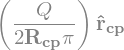

In [109]:
# the velocity
Q, phi = sp.symbols('Q phi')

phi = Q/(2*sp.pi)*sp.log(cp.R)
gradient(phi)

**Caution:** the returned velocity vector is in the transformed coordinate system, clearly the unit vectors are in that system. A transformation is required to get Cartesian components. Matplotlib's (or MATLAB's and so on) plotting functions expect Cartesian velocity components.

In [110]:
# divergence of v
divergence(gradient(phi))

In [111]:
# curl of v
curl(gradient(phi))

In [112]:
def plot_func(Q):
  # the polar velocities computed with SymPy above
  vr = Q/(2*np.pi*r)
  vth = 0

  # transform polar velocities to Cartesian ones for plotting
  vx = vr*np.cos(th) - vth*np.sin(th)
  vy = vr*np.sin(th) + vth*np.cos(th)

  fig, (ax1, ax2) = plt.subplots(1,2)

  ax1.set_xlabel('$x$')
  ax1.set_ylabel('$y$')
  ax1.set_title('quiver plot')
  ax1.set_aspect('equal')

  # skip every fourth point when plotting velocity vectors, for clarity
  ax1.quiver(x[::4,::4], y[::4,::4], vx[::4,::4], vy[::4,::4],
              scale=0.1, scale_units='xy', color='blue')

  ax2.set_xlabel('$x$')
  ax2.set_ylabel('$y$')
  ax2.set_title('stream plot')
  ax2.set_aspect('equal')

  # clever color scaling to make the variation near z=0 less extreme
  cols = r**2*np.sqrt(vx**2+vy**2)
  strm = ax2.streamplot(x, y, vx, vy,
                        color=cols, linewidth=2,
                        cmap=colormaps['YlGnBu_r'])

  # make the colorabar look nice ...
  #pos = ax2.get_position()
  #pad, width = 0.03, 0.03
  #ax3 = fig.add_axes([pos.xmax + pad, pos.ymin + 2*pad, width, 0.7*(pos.ymax-pos.ymin) ])
  #fig.colorbar(strm.lines, cax=ax3, label="$r^2\sqrt{v_x^2+v_y^2}$")

  fig.set_size_inches(10, 8)
  plt.show()

interact(plot_func, Q = widgets.FloatSlider( value = 1,
                                             min   = -5,
                                             max   = +5,
                                             step  = 0.2 ) );

interactive(children=(FloatSlider(value=1.0, description='Q', max=5.0, min=-5.0, step=0.2), Output()), _dom_cl…

**Note:** the quiver plot is really hard to interpret near the origin due to the widly different velocity vector magnitudes there. Using `scale` helps a little.

Likewise, a 'clever' color scaling was picked to ensure the large velocities near the singularity at $z=0$ do not overwhlem the color scale. The colorbar is now not shown because the numbers aren't meaningful after the rescaling. Darker colors = faster flow.

## Ideal "doublet"

### Complex potential

Consider $F(z) = \frac{\mu}{z}$, where $\mu$ is a _real_ number (**and has nothing to do with viscosity**, don't ask me why people use this notation in their textbooks!). It is convenient to work this flow out in Cartesian coordinates by "rationalizing the denominator". We can show that
\begin{align*}
\phi(x,y) &= \mathrm{Re}[F] =  \frac{\mu x}{x^2+y^2},\\
\psi(x,y) &= \mathrm{Im}[F] = -\frac{\mu y}{x^2+y^2}.
\end{align*}

Let's plot the <font color="red">equipotential</font> and <font color="blue">stream</font> lines, and vary $\mu$.

In [ ]:
def plot_func(μ):
  phi = μ*x/(x**2 + y**2)
  psi = -μ*y/(x**2 + y**2)

  fig, ax = plt.subplots()
  ax.set_xlabel('$x$')
  ax.set_ylabel('$y$')
  ax.set_aspect('equal')

  # plot contour lines corresponding to planar curves y = f(x) of constant phi
  # of values between -10 and 10; these are the "equipotential lines"
  levels = np.arange(-10, 10, 1)
  csphi = ax.contour(x, y, phi, levels, colors='red')

  # plot contour lines corresponding to planar curves y = f(x) of constant psi
  # of values between -10 and 10; these are the "stream lines"
  levels = np.arange(-10, 10, 1)
  cspsi = ax.contour(x, y, psi, levels, colors='blue')

  # label the contours with their values
  ax.clabel(csphi, inline=1, fontsize=10)
  ax.clabel(cspsi, inline=1, fontsize=10)

  fig.set_size_inches(8, 6)
  plt.show()

# the mu range is chosen to capture variations
interact(plot_func, μ = widgets.FloatSlider( value = 10,
                                             min   = -30,
                                             max   = +30,
                                             step  = 2 ) );

interactive(children=(FloatSlider(value=10.0, description='μ', max=30.0, min=-30.0, step=2.0), Output()), _dom…

### Velocity profile

We find it two ways.

First, we find the complex velocity:
\begin{align*}
  W(z) = \frac{dF}{dz} = -\frac{\mu}{z^2} &= -\frac{\mu}{x^2 - y^2 + 2ixy}\\
  & =-\mu\frac{x^2 - y^2 - 2ixy}{(x^2 - y^2)^2 + 4x^2y^2}\\
  & = {\color{magenta}{-\frac{\mu}{(x^2 + y^2)^2}}} [ {\color{magenta}{x^2 - y^2}} {\color{red}{- i}} ({\color{magenta}{2xy}}) ].
\end{align*}
From which we read off the <font color="magenta">magenta</font> terms (the red ones have to be there in the definition relating the velocity components to $W$):
\begin{align*}
  v_x(x,y) &= -\frac{\mu}{(x^2 + y^2)^2} (x^2-y^2),\\
  v_y(x,y) &= -\frac{\mu}{(x^2 + y^2)^2} 2xy.\\
\end{align*}

We can check our work with SymPy.

In [114]:
x_s, y_s = sp.symbols('x_s y_s', real='True') # _s for "symbolic", different from plotting vars
#sp.factor(sp.simplify((x_s**2 - y_s**2)**2 + 4*x_s**2*y_s**2))

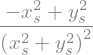

In [115]:
sp.simplify(sp.re(-1/(x_s + sp.I*y_s)**2))

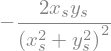

In [116]:
-sp.im(-1/(x_s + sp.I*y_s)**2)

Second, we compute $\underline{v} = \nabla \phi$ in Cartesian coordinates directly using SymPy's [`vector`](https://docs.sympy.org/latest/modules/vector/index.html) module:

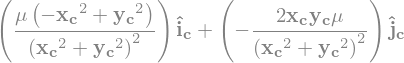

In [117]:
mu, phi = sp.symbols('mu phi')
c = CoordSys3D('c')

phi = mu*c.x/(c.x**2+c.y**2)

# the velocity
sp.simplify(gradient(phi))

In [118]:
# divergence of v, calling simplify to reduce the expression
# (for fun see what it prints out without simplify)
sp.simplify(divergence(gradient(phi)))

In [119]:
# curl of v
curl(gradient(phi))

This time the velocity vector is returned in Cartesian coordinates, so we don't have to do anything futher!

In [ ]:
def plot_func(μ):
  vx = -μ*(x**2 - y**2)/(x**2 + y**2)**2
  vy = -2*x*y*μ/(x**2 + y**2)**2

  fig, (ax1, ax2) = plt.subplots(1,2)

  ax1.set_xlabel('$x$')
  ax1.set_ylabel('$y$')
  ax1.set_title('quiver plot')
  ax1.set_aspect('equal')

  # skip every fourth point when plotting velocity vectors, for clarity
  ax1.quiver(x[::4,::4], y[::4,::4], vx[::4,::4], vy[::4,::4],
              scale=5, scale_units='xy', color='blue')

  ax2.set_xlabel('$x$')
  ax2.set_ylabel('$y$')
  ax2.set_title('stream plot')
  ax2.set_aspect('equal')

  # clever color scaling to make the variation near z=0 less extreme
  cols = r**3*np.sqrt(vx**2+vy**2)
  strm = ax2.streamplot(x, y, vx, vy,
                        color=cols, linewidth=2,
                        cmap=colormaps['YlGnBu_r'])

  # make the colorabar look nice ...
  #pos = ax2.get_position()
  #pad, width = 0.03, 0.03
  #ax3 = fig.add_axes([pos.xmax + pad, pos.ymin + 2*pad, width, 0.7*(pos.ymax-pos.ymin) ])
  #fig.colorbar(strm.lines, cax=ax3, label='$r^3\sqrt{v_x^2+v_y^2}$')

  fig.set_size_inches(10, 8)
  plt.show()

interact(plot_func, μ = widgets.FloatSlider( value = 10,
                                             min   = -30,
                                             max   = +30,
                                             step  = 2 ) );

interactive(children=(FloatSlider(value=10.0, description='μ', max=30.0, min=-30.0, step=2.0), Output()), _dom…

**Note:** the quiver plot is really hard to interpret near the $y=0$ due to the widly different velocity vector magnitudes there. Using `scale` helps a little.

Likewise, a 'clever' color scaling was picked to ensure the large velocities near the singularity at $z=0$ do not overwhlem the color scale. The colorbar is now not shown because the numbers aren't meaningful after the rescaling. Darker colors = faster flow.